In [75]:
import pandas as pd
import numpy

import matplotlib.pyplot as plt
import scipy
from ucimlrepo import fetch_ucirepo 

# fetch dataset 
chronic_kidney_disease = fetch_ucirepo(id=336) 
  
# data (as pandas dataframes) 
x = chronic_kidney_disease.data.features 
y = chronic_kidney_disease.data.targets 
  
# metadata 
# print(chronic_kidney_disease.metadata) 
  
# variable information 
print(chronic_kidney_disease.variables)

#adds target to df 
#other option was something like: pd.merge(x,y,on='id',how='left')
df = pd.concat([x, y], axis=1)

#removes columns not wanted
df.drop(columns=[
    'rbc',
    'pc',
    'pcc',
    'ba',
    'sc',
    'htn',
    'dm',
    'cad',
    'appet',
    'pe',
    'ane'
], inplace=True)

#hemoglobin changed from g/dl to g/l
df['hemo'] = df['hemo']*10

#filtering potand bp values (i filter the values on purpose before removing rows with too many missing values)
df['pot'] = df['pot'].apply(lambda x: x if  x <= 40 else None)
df['bp'] = df['bp'].apply(lambda x: x if  x <= 170 else None)

#class ckd changed to a and notckd changed to c
df['class'] =df['class'].replace({'ckd':'a','notckd':'c'})

#filtering out rows with too many empty values (if data has custom values for empty data like 0 instead of NaN i dont know if .insa() will work)
#printing dataframe lenght before and after
print(len(df))
df = df[df.isna().sum(axis=1) < 3]
print(len(df))

#dataframe for affected:
dfa = df[df['class'] == 'a']
print(len(dfa))
print(dfa)
#dataframe for control
dfc = df[df['class'] == 'c']
print(len(dfc))
print(dfc)


def plot_data(df):
    plt.figure(figsize=(20, 10))
    for i, col in enumerate(df.select_dtypes(include=['int', 'float'])):
        plt.subplot(3, 5, i + 1)
        df[col].plot(kind='hist', title=col)
        plt.xlabel(col)
        plt.tight_layout()





     name     role         type demographic              description  \
0     age  Feature      Integer         Age                      NaN   
1      bp  Feature      Integer         NaN           blood pressure   
2      sg  Feature  Categorical         NaN         specific gravity   
3      al  Feature  Categorical         NaN                  albumin   
4      su  Feature  Categorical         NaN                    sugar   
5     rbc  Feature       Binary         NaN          red blood cells   
6      pc  Feature       Binary         NaN                 pus cell   
7     pcc  Feature       Binary         NaN          pus cell clumps   
8      ba  Feature       Binary         NaN                 bacteria   
9     bgr  Feature      Integer         NaN     blood glucose random   
10     bu  Feature      Integer         NaN               blood urea   
11     sc  Feature   Continuous         NaN         serum creatinine   
12    sod  Feature      Integer         NaN                   so

In [76]:
print(df)

      age    bp     sg   al   su    bgr    bu    sod  pot   hemo   pcv  \
0    48.0  80.0  1.020  1.0  0.0  121.0  36.0    NaN  NaN  154.0  44.0   
3    48.0  70.0  1.005  4.0  0.0  117.0  56.0  111.0  2.5  112.0  32.0   
4    51.0  80.0  1.010  2.0  0.0  106.0  26.0    NaN  NaN  116.0  35.0   
5    60.0  90.0  1.015  3.0  0.0   74.0  25.0  142.0  3.2  122.0  39.0   
6    68.0  70.0  1.010  0.0  0.0  100.0  54.0  104.0  4.0  124.0  36.0   
..    ...   ...    ...  ...  ...    ...   ...    ...  ...    ...   ...   
395  55.0  80.0  1.020  0.0  0.0  140.0  49.0  150.0  4.9  157.0  47.0   
396  42.0  70.0  1.025  0.0  0.0   75.0  31.0  141.0  3.5  165.0  54.0   
397  12.0  80.0  1.020  0.0  0.0  100.0  26.0  137.0  4.4  158.0  49.0   
398  17.0  60.0  1.025  0.0  0.0  114.0  50.0  135.0  4.9  142.0  51.0   
399  58.0  80.0  1.025  0.0  0.0  131.0  18.0  141.0  3.5  158.0  53.0   

       wbcc  rbcc class  
0    7800.0   5.2     a  
3    6700.0   3.9     a  
4    7300.0   4.6     a  
5    78

In [77]:
dfa.describe(include='all')



,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
count,123.000000,124.000000,125.000000,126.000000,126.000000,120.000000,125.000000,108.000000,107.000000,125.000000,125.000000,113.000000,108.000000,126
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126
mean,57.081301,79.919355,1.013560,1.849206,0.809524,181.200000,80.420000,133.731481,4.357009,106.432000,32.440000,9450.442478,3.976852,NaN
std,14.465104,13.035035,0.004527,1.437038,1.366539,93.549394,60.501346,7.666661,0.916938,21.896507,7.150908,3720.458015,0.844510,NaN
min,6.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,104.000000,2.500000,31.000000,9.000000,2600.000000,2.100000,NaN
25%,49.500000,70.000000,1.010000,0.250000,0.000000,107.000000,37.000000,131.750000,3.800000,95.000000,29.000000,7100.000000,3.400000,NaN
50%,60.000000,80.000000,1.015000,2.000000,0.000000,158.000000,60.000000,136.000000,4.200000,108.000000,33.000000,9200.000000,3.900000,NaN
75%,65.000000,90.000000,1.015000,3.000000,1.000000,241.250000,107.000000,139.000000,4.900000,120.000000,37.000000,11000.000000,4.400000,NaN


In [78]:
dfc.describe(include='all')

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
count,139.000000,137.000000,139.000000,139.0,139.0,135.000000,135.000000,136.000000,136.000000,137.000000,138.000000,136.000000,136.000000,139
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,139
mean,46.568345,71.313869,1.022482,0.0,0.0,107.385185,32.874074,141.735294,4.335294,151.883212,46.246377,7708.088235,5.380882,NaN
std,15.903719,8.559267,0.002509,0.0,0.0,18.747730,11.482257,4.792332,0.596351,12.845270,4.107695,1815.164727,0.592986,NaN
min,12.000000,60.000000,1.020000,0.0,0.0,70.000000,10.000000,135.000000,3.300000,130.000000,40.000000,4300.000000,4.500000,NaN
25%,34.000000,60.000000,1.020000,0.0,0.0,93.000000,23.500000,138.000000,3.700000,141.000000,43.000000,6300.000000,4.900000,NaN
50%,46.000000,70.000000,1.020000,0.0,0.0,107.000000,33.000000,141.000000,4.500000,150.000000,46.000000,7450.000000,5.300000,NaN
75%,58.000000,80.000000,1.025000,0.0,0.0,123.500000,44.000000,146.000000,4.900000,162.000000,50.000000,9225.000000,5.900000,NaN


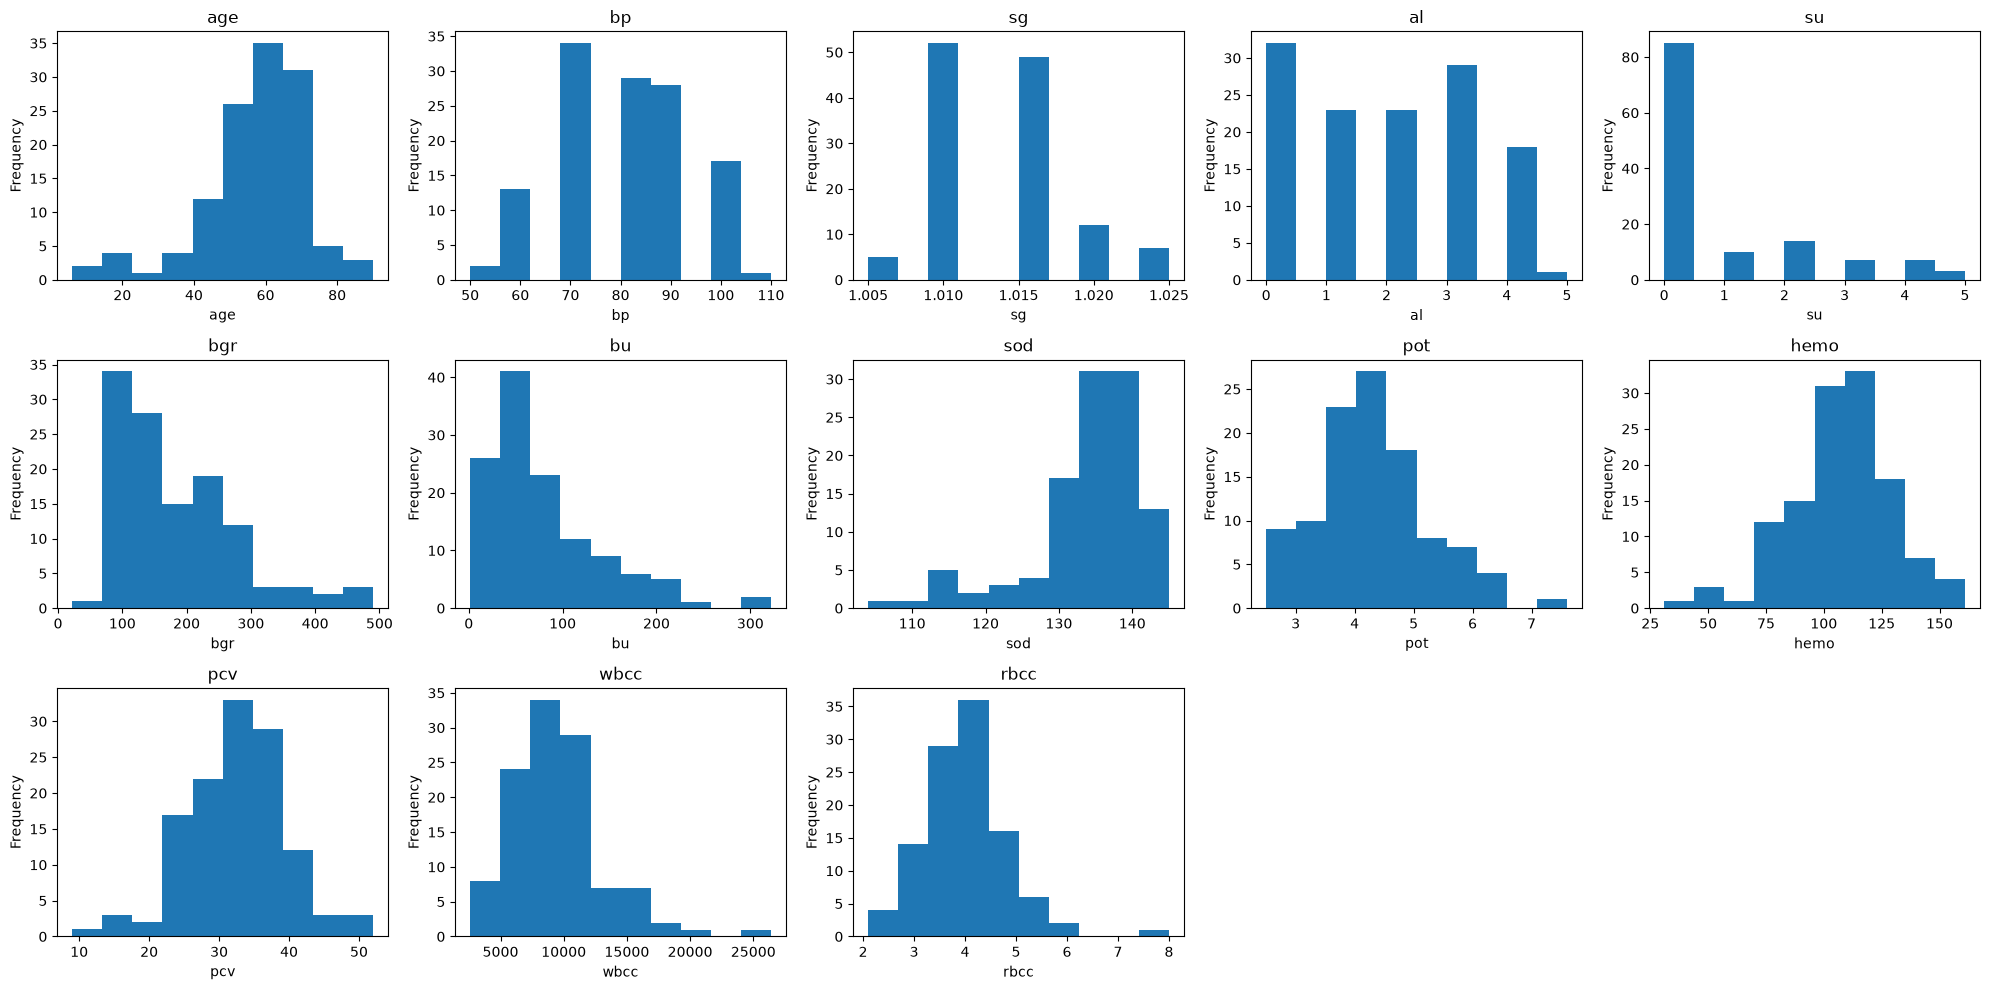

In [79]:
plot_data(dfa)

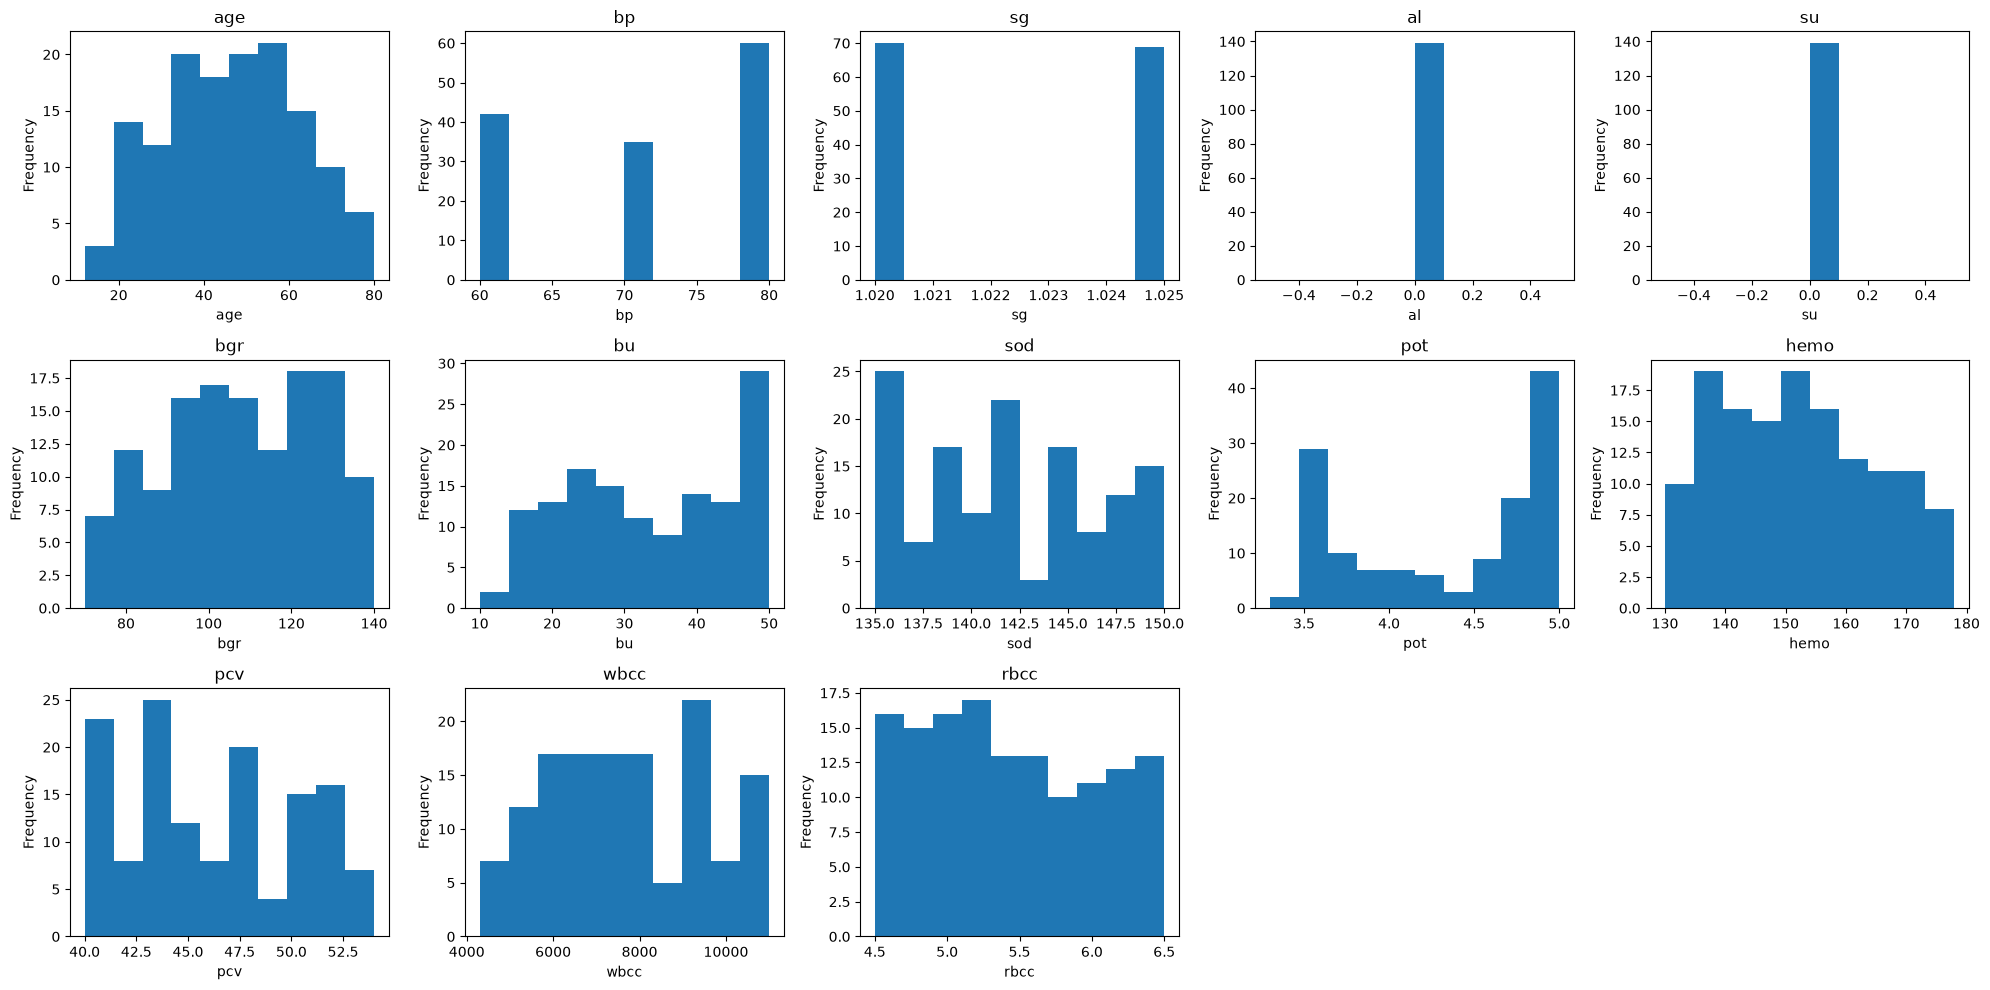

In [80]:
plot_data(dfc)

In [81]:
#clear outliers in data
#i would have to be a medical professional to correctly filter all of them.
#i will simply remove the most outrageus outliers in pot,bp

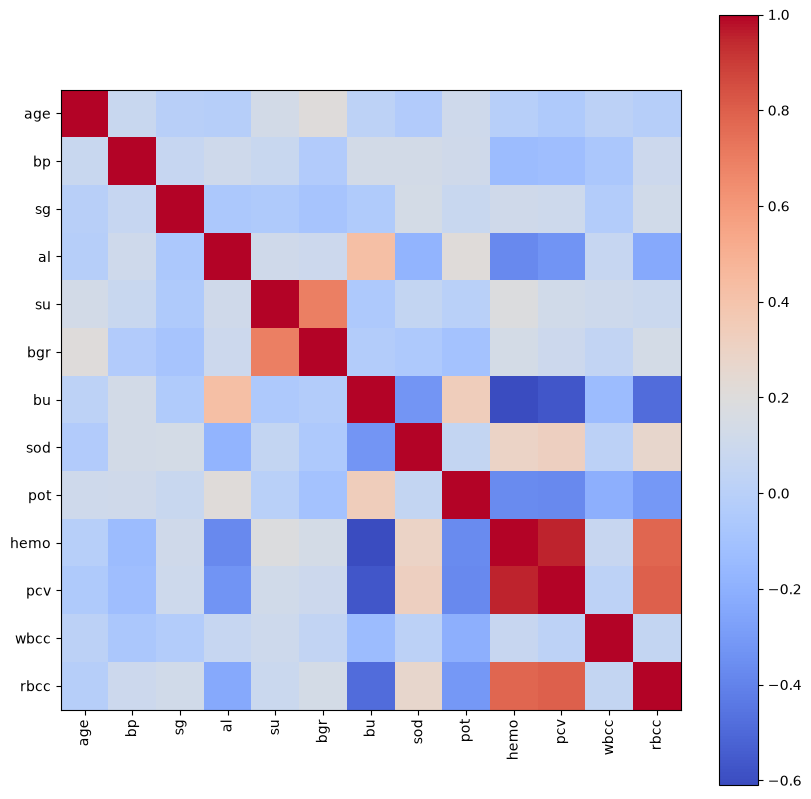

In [82]:
corr_a = dfa.drop(columns=['class']).corr()
corr_a

plt.figure(figsize=(10, 10))
plt.imshow(corr_a, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr_a)), corr_a.columns, rotation=90)
plt.yticks(range(len(corr_a)), corr_a.columns)
plt.show()


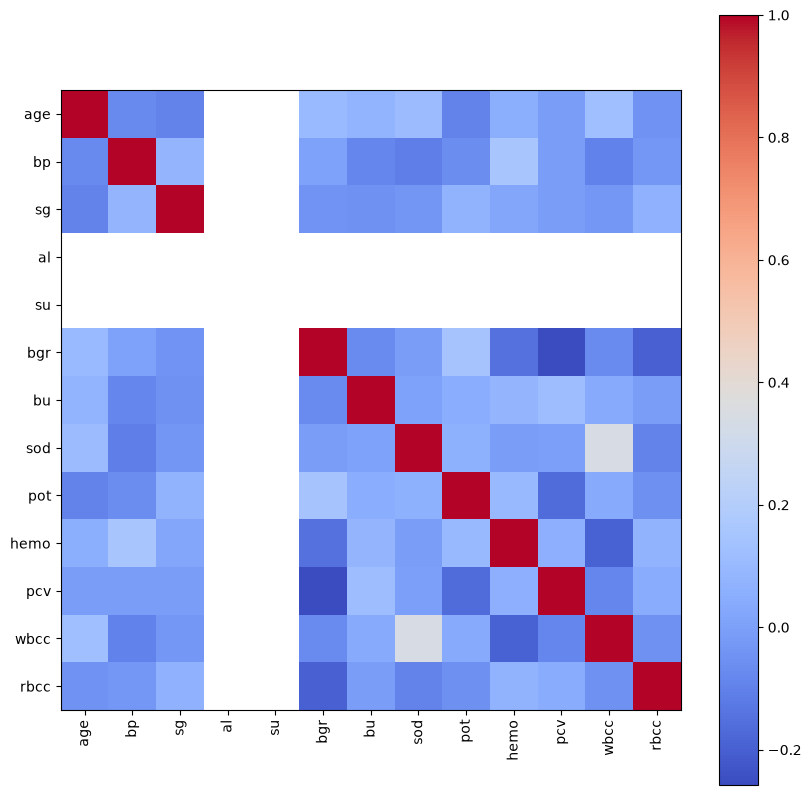

In [83]:
corr_c = dfc.drop(columns=['class']).corr()
corr_c

plt.figure(figsize=(10, 10))
plt.imshow(corr_c, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr_c)), corr_c.columns, rotation=90)
plt.yticks(range(len(corr_c)), corr_c.columns)
plt.show()

In [ ]:
#first thing of note is that control group has no sugar or albunim in samples.
#sugar in pee higly correlates with sugar in blood
#in control group pvc negatively correlates with bgr but in affected group not so much.
#high hemoglobin correlates with high rbcc in affected but it should obviously also correlate higly in control
#but it doesnt as in control people just dot have high hemoglobin/rbcc values